# `flowrep` and `semantikon`

Here we give basic introductions to `flowrep` and `semantikon` and show how they form a pipeline for ontologically-annotated workflows.

## `flowrep` at 30,000 ft


### **Core concept:** recipes can be generated from easy-to-write python code

Workflow syntax is slightly restricted but very natural feeling.

In [1]:
import flowrep as fr

def my_add(a, b):
    return a + b

@fr.atomic("product")  # Optional for atomic nodes, but can configure recipe aspects
def my_mul(a, b):
    return a * b

@fr.workflow
def linear(m, x, b):
    first_order = my_mul(m, x)
    y = my_add(first_order, b)
    return y

### **Core concept:** `flowrep`-decorated functions are still just functions!

In [2]:
type(linear), linear(2, 2, 0.5)

(function, 4.5)

`flowrep` information is merely added as data onto the function object

In [3]:
linear.flowrep_recipe

WorkflowRecipe(type=<RecipeElementType.WORKFLOW: 'workflow'>, inputs=['m', 'x', 'b'], outputs=['y'], description=None, nodes={'my_mul_0': AtomicRecipe(type=<RecipeElementType.ATOMIC: 'atomic'>, inputs=['a', 'b'], outputs=['product'], description=None, reference=PythonReference(info=VersionInfo(module='__main__', qualname='my_mul', version=None), inputs_with_defaults=[], restricted_input_kinds={}), unpack_mode=<UnpackMode.TUPLE: 'tuple'>), 'my_add_0': AtomicRecipe(type=<RecipeElementType.ATOMIC: 'atomic'>, inputs=['a', 'b'], outputs=['output_0'], description=None, reference=PythonReference(info=VersionInfo(module='__main__', qualname='my_add', version=None), inputs_with_defaults=[], restricted_input_kinds={}), unpack_mode=<UnpackMode.TUPLE: 'tuple'>)}, input_edges={TargetHandle(node='my_mul_0', port='a'): InputSource(node=None, port='m'), TargetHandle(node='my_mul_0', port='b'): InputSource(node=None, port='x'), TargetHandle(node='my_add_0', port='b'): InputSource(node=None, port='b')},

### **Core concept:** Recipes are trivially serializable to JSON.

In [4]:
linear.flowrep_recipe.model_dump(mode="json")

{'type': 'workflow',
 'inputs': ['m', 'x', 'b'],
 'outputs': ['y'],
 'description': None,
 'nodes': {'my_mul_0': {'type': 'atomic',
   'inputs': ['a', 'b'],
   'outputs': ['product'],
   'description': None,
   'reference': {'info': {'module': '__main__',
     'qualname': 'my_mul',
     'version': None},
    'inputs_with_defaults': [],
    'restricted_input_kinds': {}},
   'unpack_mode': 'tuple'},
  'my_add_0': {'type': 'atomic',
   'inputs': ['a', 'b'],
   'outputs': ['output_0'],
   'description': None,
   'reference': {'info': {'module': '__main__',
     'qualname': 'my_add',
     'version': None},
    'inputs_with_defaults': [],
    'restricted_input_kinds': {}},
   'unpack_mode': 'tuple'}},
 'input_edges': {'my_mul_0.a': 'm', 'my_mul_0.b': 'x', 'my_add_0.b': 'b'},
 'edges': {'my_add_0.a': 'my_mul_0.product'},
 'output_edges': {'y': 'my_add_0.output_0'},
 'reference': {'info': {'module': '__main__',
   'qualname': 'linear',
   'version': None},
  'inputs_with_defaults': [],
  'rest

Indeed, you could even _start_ by writing your recipe in JSON in some text editor, it gets you to the same recipe.

In [5]:
import pathlib

path = pathlib.Path("recipe.json")

# Round-trip the recipe to the filesystem and back
path.write_text(linear.flowrep_recipe.model_dump_json())
reloaded_recipe = fr.schemas.WorkflowRecipe.model_validate_json(path.read_text())

# Cleanup
path.unlink()

# Compare
reloaded_recipe == linear.flowrep_recipe

True

### **Core concept:** `flowrep` also provides a _retrospective_ data format.

We can generate an empty data container directly from each recipe, and use a WfMS to fill it up. `flowrep` comes with a little toy WfMS to demonstrate this:

In [6]:
data = fr.tools.run_recipe(linear.flowrep_recipe, m=2, x=2, b=0.5)

The output data contains the recipe that generated it

In [7]:
data.recipe.model_dump(mode="json")

{'type': 'workflow',
 'inputs': ['m', 'x', 'b'],
 'outputs': ['y'],
 'description': None,
 'nodes': {'my_mul_0': {'type': 'atomic',
   'inputs': ['a', 'b'],
   'outputs': ['product'],
   'description': None,
   'reference': {'info': {'module': '__main__',
     'qualname': 'my_mul',
     'version': None},
    'inputs_with_defaults': [],
    'restricted_input_kinds': {}},
   'unpack_mode': 'tuple'},
  'my_add_0': {'type': 'atomic',
   'inputs': ['a', 'b'],
   'outputs': ['output_0'],
   'description': None,
   'reference': {'info': {'module': '__main__',
     'qualname': 'my_add',
     'version': None},
    'inputs_with_defaults': [],
    'restricted_input_kinds': {}},
   'unpack_mode': 'tuple'}},
 'input_edges': {'my_mul_0.a': 'm', 'my_mul_0.b': 'x', 'my_add_0.b': 'b'},
 'edges': {'my_add_0.a': 'my_mul_0.product'},
 'output_edges': {'y': 'my_add_0.output_0'},
 'reference': {'info': {'module': '__main__',
   'qualname': 'linear',
   'version': None},
  'inputs_with_defaults': [],
  'rest

And IO information

In [8]:
data.input_ports, data.output_ports

({'m': InputDataPort(value=2, annotation=None, default=NOT_DATA),
  'x': InputDataPort(value=2, annotation=None, default=NOT_DATA),
  'b': InputDataPort(value=0.5, annotation=None, default=NOT_DATA)},
 {'y': OutputDataPort(value=4.5, annotation=None)})

Everything is available recursively down to atomic nodes

In [9]:
for label, subresult in data.nodes.items():
    print(label, subresult.output_ports)

my_mul_0 {'product': OutputDataPort(value=4, annotation=None)}
my_add_0 {'output_0': OutputDataPort(value=4.5, annotation=None)}


Since this has arbitrary python objects as the port values, we can't serialize it to JSON. `bagofholding` is the recommended solution

In [10]:
import bagofholding

path = pathlib.Path("data-bag.h5")
bagofholding.H5Bag.save(data, path)

We have a convenient browser in this case

In [11]:
browser = fr.tools.LexicalBagBrowser(path)
browser.browse()

LexicalBagTree(multiple_selection=False, nodes=(Node(close_icon_style='danger', name='Workflow', nodes=(Node(c…

In [12]:
browser.load("my_add_0.inputs.a")

InputDataPort(value=4, annotation=None, default=NOT_DATA)

In [13]:
path.unlink()

### **Core concept:** `flowrep` handles complex graphs

I.e. nesting, for-each, if, try, and while.

As before, the heart of this is the pydantic model and you can write such recipes in a text editor and save to JSON, but we try to make it feel as natural as possible to write them with decorated python.

In [14]:
def identity(x):
    return x

def my_condition(m, n):
    return m < n

def my_range(n):
    return list(range(n))

def my_sum(lst: list[int]) -> int:
    total = sum(lst)
    return total

@fr.workflow
def full_composite(x, /, y, *, bound):
    """
    Nests all four flow controls with sibling context at every level:
      top-level workflow, siblings around try
        try / except, siblings around while
          while, siblings around for
            for, if/else inside body
    """
    a = my_add(x, y)

    # --- try (level 1) ---
    try:
        b = my_mul(a, y)

        # --- while (level 2) ---
        while my_condition(b, bound):  # **While conditions must be a single callable**
            c = my_add(b, y)
            rs = my_range(c)

            # --- for (level 3) ---
            acc = []  # **For-loops accumulate output to lists**
            for r in rs:
                # --- if/else (level 4) ---
                if my_condition(r, y):
                    v = my_add(r, c)
                else:
                    v = my_mul(r, c)
                acc.append(v)

            b = my_sum(acc)

        z = identity(b)
    except ValueError:
        z = identity(a)

    # --- sibling after try ---
    result = identity(z)
    return result

In [15]:
full_composite.flowrep_recipe.model_dump(mode="json")

{'type': 'workflow',
 'inputs': ['x', 'y', 'bound'],
 'outputs': ['result'],
 'description': 'Nests all four flow controls with sibling context at every level:\n  top-level workflow, siblings around try\n    try / except, siblings around while\n      while, siblings around for\n        for, if/else inside body',
 'nodes': {'my_add_0': {'type': 'atomic',
   'inputs': ['a', 'b'],
   'outputs': ['output_0'],
   'description': None,
   'reference': {'info': {'module': '__main__',
     'qualname': 'my_add',
     'version': None},
    'inputs_with_defaults': [],
    'restricted_input_kinds': {}},
   'unpack_mode': 'tuple'},
  'try_0': {'type': 'try',
   'inputs': ['a', 'y', 'bound'],
   'outputs': ['b', 'z'],
   'description': None,
   'try_node': {'label': 'try_body',
    'node': {'type': 'workflow',
     'inputs': ['a', 'y', 'bound'],
     'outputs': ['b', 'z'],
     'description': None,
     'nodes': {'my_mul_0': {'type': 'atomic',
       'inputs': ['a', 'b'],
       'outputs': ['product'

In [16]:
composite_wf_data = fr.tools.run_recipe(full_composite.flowrep_recipe, x=1, y=2, bound=10)
composite_wf_data.output_ports

{'result': OutputDataPort(value=233, annotation=None)}

## **Interaction:** `flowrep` ↔  `python-workflow-definition`

PWD does not support nested workflows or flow controls, but inside these constraints we can bi-directionally convert between the two representations.

Beyond this, PWD also stores terminal input data as part of the recipe (and hopes it is JSONable). When converting back-and-forth, these values are either required or returned.

In [17]:
pwd_recipe = fr.tools.flowrep2pwd(linear.flowrep_recipe, m=2, x=2, b=0.5)
pwd_recipe.model_dump(mode="json")

{'version': '0.0.1',
 'nodes': [{'id': 0, 'type': 'input', 'name': 'm', 'value': 2},
  {'id': 1, 'type': 'input', 'name': 'x', 'value': 2},
  {'id': 2, 'type': 'input', 'name': 'b', 'value': 0.5},
  {'id': 3, 'type': 'output', 'name': 'y'},
  {'id': 4, 'type': 'function', 'value': '__main__.my_mul'},
  {'id': 5, 'type': 'function', 'value': '__main__.my_add'}],
 'edges': [{'target': 4, 'targetPort': 'a', 'source': 0, 'sourcePort': None},
  {'target': 4, 'targetPort': 'b', 'source': 1, 'sourcePort': None},
  {'target': 5, 'targetPort': 'a', 'source': 4, 'sourcePort': 'product'},
  {'target': 5, 'targetPort': 'b', 'source': 2, 'sourcePort': None},
  {'target': 3, 'targetPort': None, 'source': 5, 'sourcePort': 'output_0'}]}

In [18]:
import python_workflow_definition.models as pwd_models

path = pathlib.Path("pwd-recipe.json")
path.write_text(pwd_recipe.model_dump_json())

pwd_from_file = pwd_models.PythonWorkflowDefinitionWorkflow.model_validate_json(path.read_text())

path.unlink()

In [19]:
flowrep_from_pwd, terminal_inputs = fr.tools.pwd2flowrep(pwd_from_file)

run_from_pwd = fr.tools.run_recipe(flowrep_from_pwd, **terminal_inputs)
run_from_pwd.output_ports

{'y': OutputDataPort(value=4.5, annotation=None)}

The only catch is that PWD lacks certain metadata fields, so round-trips are lossy on this metadata -- e.g. no function versions.

## `semantikon` principles

TODO: @samwaseda

In [20]:
import semantikon

## **Interaction:** `flowrep` and `semantikon`

We currently have a virtuous cycle, where `flowrep` is sophisticated enough to capture `semantikon` annotations in its data format, and `semantikon` can digest that data format to produce a knoweldge graph and ontological validation report.

In [21]:
import rdflib

EX = rdflib.Namespace("http://www.example.org/")

uri_color = semantikon.SemantikonURI(EX.Color)
uri_cleaned = semantikon.SemantikonURI(EX.Cleaned)

class Clothes:
    pass

def wash(clothes: Clothes) -> semantikon.u(
    Clothes,
    triples=(EX.hasProperty, uri_cleaned),
    derived_from="inputs.clothes"
):
    ...
    return clothes

def dye(clothes: Clothes, color="blue") -> semantikon.u(
    Clothes,
    triples=(EX.hasProperty, uri_color),
    derived_from="inputs.clothes",
):
    ...
    return clothes

def sell(
    clothes: semantikon.u(
        Clothes, restrictions=(
            (
                (rdflib.OWL.onProperty, EX.hasProperty),
                (rdflib.OWL.someValuesFrom, EX.Cleaned),
            ),
            (
                (rdflib.OWL.onProperty, EX.hasProperty),
                (rdflib.OWL.someValuesFrom, EX.Color),
            )
        )
    )
) -> int:
    ...
    return 10


@fr.workflow
def my_ontological_workflow(clothes: Clothes) -> int:
    dyed_clothes = dye(clothes)
    washed_clothes = wash(dyed_clothes)
    money = sell(washed_clothes)
    return money

In [22]:
kg = semantikon.get_knowledge_graph(
    my_ontological_workflow.flowrep_recipe
)

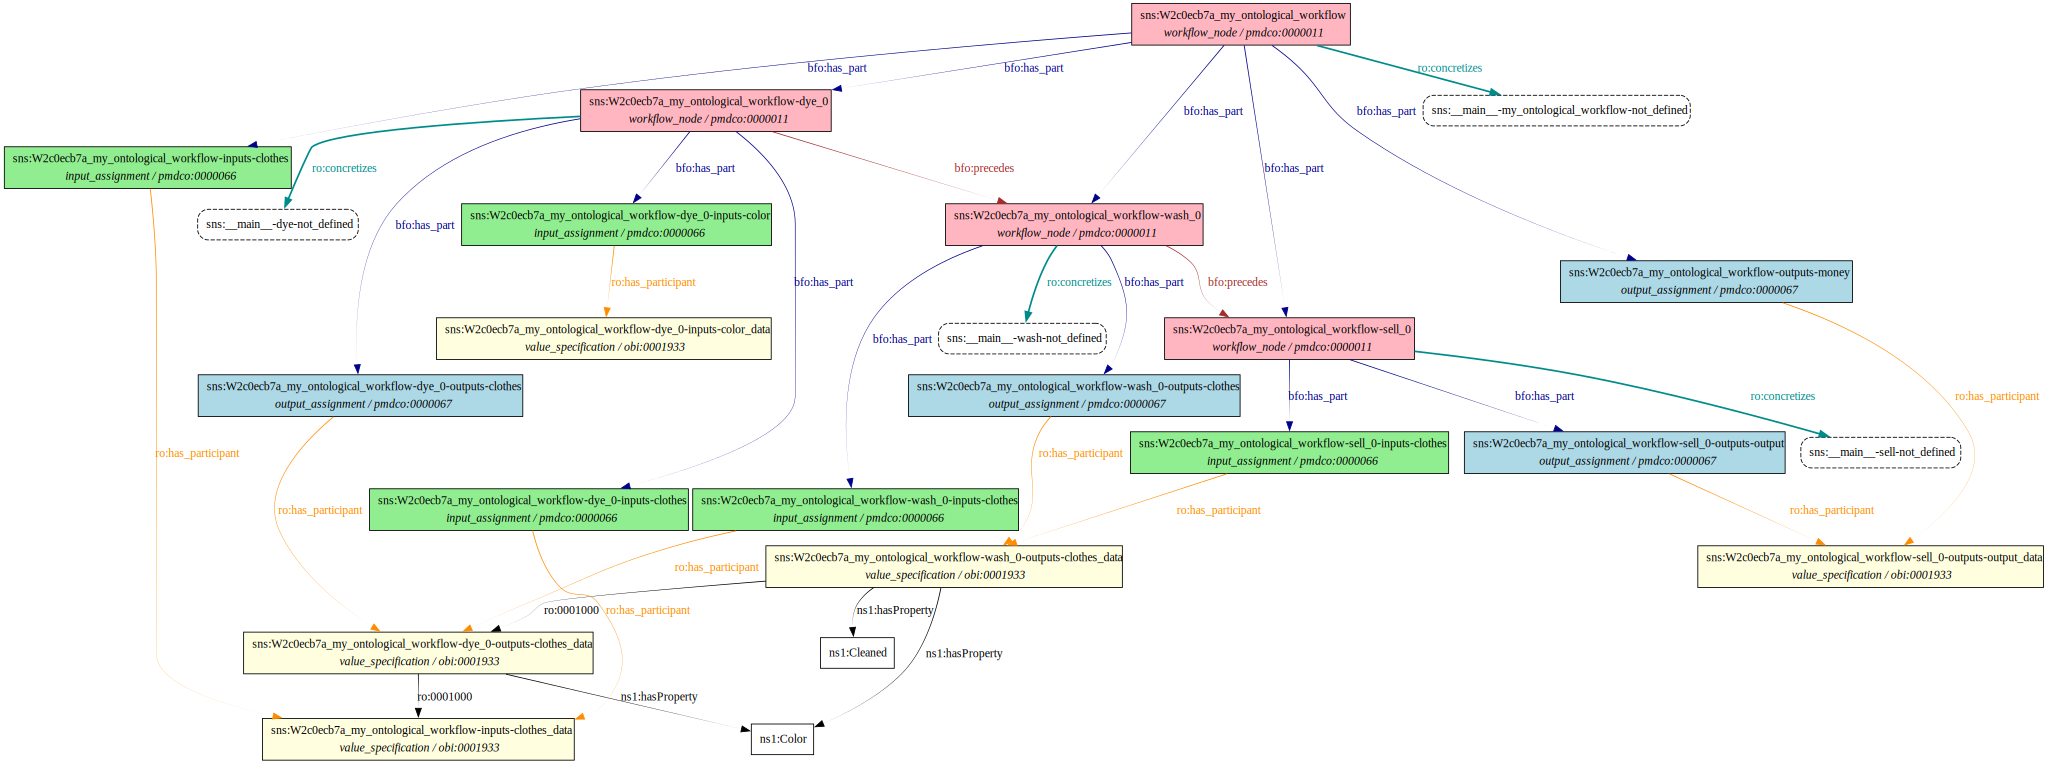

In [23]:
semantikon.visualize_recipe(kg)

In [24]:
validation_report = semantikon.validate_values(kg)
print(validation_report[2])

Validation Report
Conforms: True



Of course, if we mess up our ontological flow, the validation report nicely complains to us

In [25]:
@fr.workflow
def my_wrong_workflow(clothes: Clothes) -> int:
    washed_clothes = wash(clothes)
    money = sell(washed_clothes)
    return money

In [26]:
validation_report = semantikon.validate_values(
    my_wrong_workflow.flowrep_recipe
)
print(validation_report[2])

Validation Report
Conforms: False
Results (1):
Constraint Violation in QualifiedValueShapeConstraintComponent (http://www.w3.org/ns/shacl#QualifiedMinCountConstraintComponent):
	Severity: sh:Violation
	Source Shape: [ rdf:type sh:PropertyShape ; sh:path <http://www.example.org/hasProperty> ; sh:qualifiedMinCount Literal("1", datatype=xsd:integer) ; sh:qualifiedValueShape [ sh:class <http://www.example.org/Color> ] ]
	Focus Node: sns:5ff20d101d32e893c98b0943ec9fbc60_my_wrong_workflow-wash_0-outputs-clothes_data
	Result Path: <http://www.example.org/hasProperty>
	Message: Focus node does not conform to shape MinCount 1: [ sh:class <http://www.example.org/Color> ]

